In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import numpy as np
import random

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

c:\Users\HP\OneDrive\Desktop\AgriGuard\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.11.0+cpu
CUDA available: False


In [2]:
# Strong augmentations for training (helps model generalize better)
train_transform = A.Compose([
    A.Resize(256, 256),
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Light augmentations for validation & test (resize + normalize)
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

c:\Users\HP\OneDrive\Desktop\AgriGuard\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [3]:
class PlantVillageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        
        # Get all image paths and labels
        self.image_paths = []
        self.labels = []
        
        for class_dir in sorted(self.root_dir.iterdir()):
            if class_dir.is_dir():
                class_name = class_dir.name
                for img_path in class_dir.glob("*.jpg"):
                    self.image_paths.append(img_path)
                    self.labels.append(class_name)
        
        # Create label to index mapping
        self.class_names = sorted(list(set(self.labels)))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.class_names)}
        
        print(f"Loaded {len(self.image_paths)} images from {len(self.class_names)} classes")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.class_to_idx[self.labels[idx]]
        
        if self.transform:
            # Albumentations needs numpy array
            image_np = np.array(image)
            augmented = self.transform(image=image_np)
            image = augmented['image']
        
        return image, label

In [4]:
# Paths to your processed data
train_dir = "./data/processed_plantvillage/train"
val_dir   = "./data/processed_plantvillage/val"
test_dir  = "./data/processed_plantvillage/test"

# Create datasets
train_dataset = PlantVillageDataset(train_dir, transform=train_transform)
val_dataset   = PlantVillageDataset(val_dir,   transform=val_transform)
test_dataset  = PlantVillageDataset(test_dir,  transform=val_transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Loaded 43444 images from 38 classes
Loaded 5430 images from 38 classes
Loaded 5431 images from 38 classes
Train batches: 1358
Val batches:   170
Test batches:  170


Showing augmented training examples:


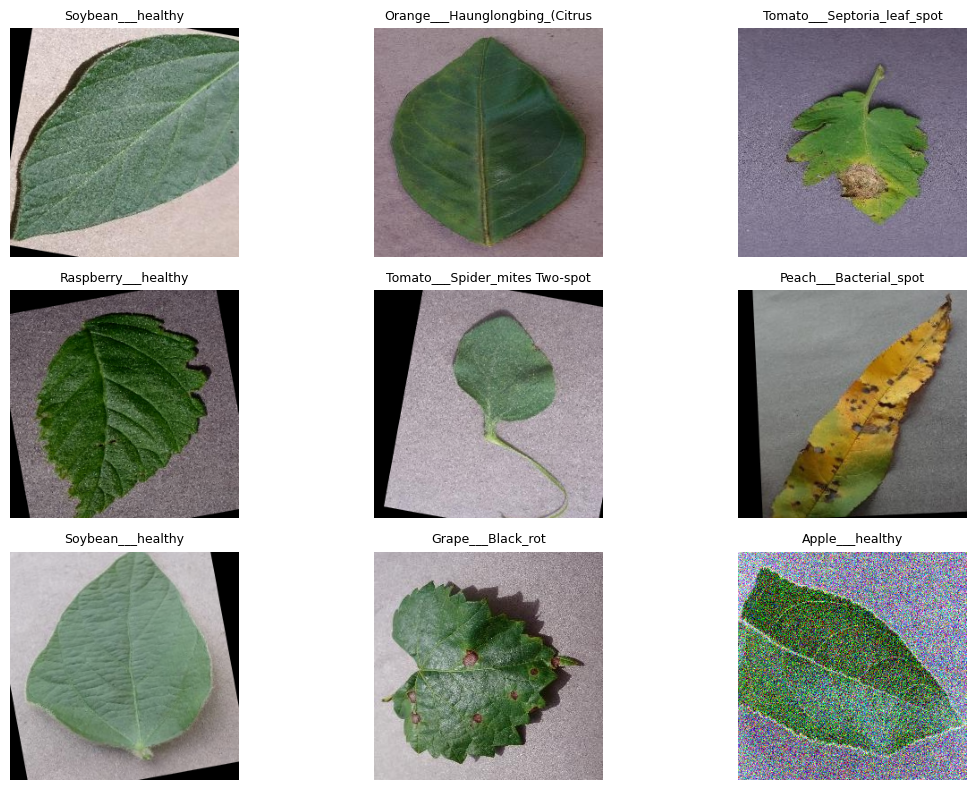

In [5]:
def show_augmented_images(dataset, num_images=9):
    plt.figure(figsize=(12, 8))
    indices = random.sample(range(len(dataset)), num_images)
    
    for i, idx in enumerate(indices):
        image, label_idx = dataset[idx]
        class_name = dataset.class_names[label_idx]
        
        # Convert tensor to numpy for display
        img_display = image.permute(1, 2, 0).numpy()
        img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)
        
        plt.subplot(3, 3, i+1)
        plt.imshow(img_display)
        plt.title(class_name[:30], fontsize=9)  # truncate long names
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Show augmented training images
print("Showing augmented training examples:")
show_augmented_images(train_dataset)